In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Better plot appearance
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

Define Project Paths

In [3]:
PROJECT_PATH = "/content/drive/MyDrive/AI_Projects/Customer_Review_Insight_Engine"
DATA_PATH = os.path.join(PROJECT_PATH, "data")

csv_path = os.path.join(DATA_PATH, "amazon_reviews.csv")

print(csv_path)

/content/drive/MyDrive/AI_Projects/Customer_Review_Insight_Engine/data/amazon_reviews.csv


Load the dataset

In [4]:
df = pd.read_csv(csv_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (50000, 10)


,Unnamed: 0,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,0,A2HD75EMZR8QLN,0700099867,123,"[8, 12]",Installing the game was a struggle (because of...,0.0,Pay to unlock content? I don't think so.,1341792000,"07 9, 2012"
1,1,A3UR8NLLY1ZHCX,0700099867,"Alejandro Henao ""Electronic Junky""","[0, 0]",If you like rally cars get this game you will ...,3.0,Good rally game,1372550400,"06 30, 2013"
2,2,A1INA0F5CWW3J4,0700099867,"Amazon Shopper ""Mr.Repsol""","[0, 0]",1st shipment received a book instead of the ga...,0.0,Wrong key,1403913600,"06 28, 2014"
3,4,A361M14PU2GUEG,0700099867,"Angry Ryan ""Ryan A. Forrest""","[2, 2]",I had Dirt 2 on Xbox 360 and it was an okay ga...,3.0,DIRT 3,1308009600,"06 14, 2011"
4,5,A2UTRVO4FDCBH6,0700099867,A.R.G.,"[0, 0]","Overall this is a well done racing game, with ...",3.0,"Good racing game, terrible Windows Live Requir...",1368230400,"05 11, 2013"


Basic Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      50000 non-null  int64  
 1   reviewerID      50000 non-null  object 
 2   asin            50000 non-null  object 
 3   reviewerName    49872 non-null  object 
 4   helpful         50000 non-null  object 
 5   reviewText      49998 non-null  object 
 6   overall         50000 non-null  float64
 7   summary         49990 non-null  object 
 8   unixReviewTime  50000 non-null  int64  
 9   reviewTime      50000 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 3.8+ MB


Missing Values Check

In [6]:
df.isnull().sum

<bound method DataFrame.sum of        Unnamed: 0  reviewerID   asin  reviewerName  helpful  reviewText  \
0           False       False  False         False    False       False   
1           False       False  False         False    False       False   
2           False       False  False         False    False       False   
3           False       False  False         False    False       False   
4           False       False  False         False    False       False   
...           ...         ...    ...           ...      ...         ...   
49995       False       False  False         False    False       False   
49996       False       False  False         False    False       False   
49997       False       False  False         False    False       False   
49998       False       False  False         False    False       False   
49999       False       False  False         False    False       False   

       overall  summary  unixReviewTime  reviewTime  
0        False    False           False       False  
1        False    False           False       False  
2        False    False           False       False  
3        False    False           False       False  
4        False    False           False       False  
...        ...      ...             ...         ...  
49995    False    False           False       False  
49996    False    False           False       False  
49997    False    False           False       False  
49998    False    False           False       False  
49999    False    False           False       False  

[50000 rows x 10 columns]>

Statistical Summary

In [7]:
df.describe(include='all')

,Unnamed: 0,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
count,50000.000000,50000,50000,49872,50000,49998,50000.000000,49990,5.000000e+04,50000
unique,NaN,10871,3400,10238,1173,49992,NaN,44020,NaN,5228
top,NaN,A3V6Z4RCDGRC44,B0009VXBAQ,Amazon Customer,"[0, 0]",love it,NaN,Great Game,NaN,"03 24, 2003"
freq,NaN,239,371,242,16794,2,NaN,207,NaN,65
mean,29228.090600,NaN,NaN,NaN,NaN,NaN,3.132300,NaN,1.148879e+09,NaN
std,17208.295237,NaN,NaN,NaN,NaN,NaN,1.171744,NaN,1.303656e+08,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,9.398592e+08,NaN
25%,14353.750000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,1.042762e+09,NaN
50%,28823.500000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,1.112227e+09,NaN
75%,43942.250000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,1.249862e+09,NaN


Rating Distribution

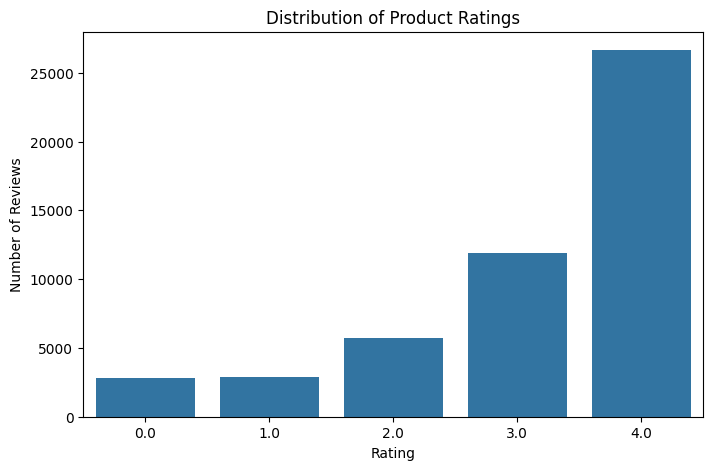

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x='overall', data=df)
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

📈 Business Interpretation of Your Chart
Key Observation

The dataset is heavily skewed toward high ratings, especially 5-star reviews.

Approximate Distribution
⭐ 5-star reviews: ~27,000
⭐ 4-star reviews: ~12,000
⭐ 3-star reviews: ~6,000
⭐ 2-star reviews: ~3,000
⭐ 1-star reviews: ~3,000

🧠 Business Insights
Positive Findings

Most customers are satisfied with the products.

Important Opportunity

Even a few thousand negative reviews contain highly valuable information about:

Product defects
Delivery issues
Packaging problems
Performance concerns
Business Value

Companies often focus on these negative reviews because they reveal actionable problems.

It will answer questions like:

What are the top complaints in 1- and 2-star reviews?
Which issues occur most frequently?
What improvements should the company prioritize?
How can customer satisfaction be increased?

This is where the project becomes genuinely useful.

Step 2.1: Review Length Analysis
Longer reviews often contain richer details and more actionable feedback

Create Review Length Feature

In [9]:
df['review_length'] = df['reviewText'].astype(str).apply(len)

print(df['review_length'].describe())

count    50000.000000
mean       748.344780
std        535.729275
min          3.000000
25%        304.000000
50%        615.000000
75%       1090.250000
max       2410.000000
Name: review_length, dtype: float64


Visualize Review Length Distribution

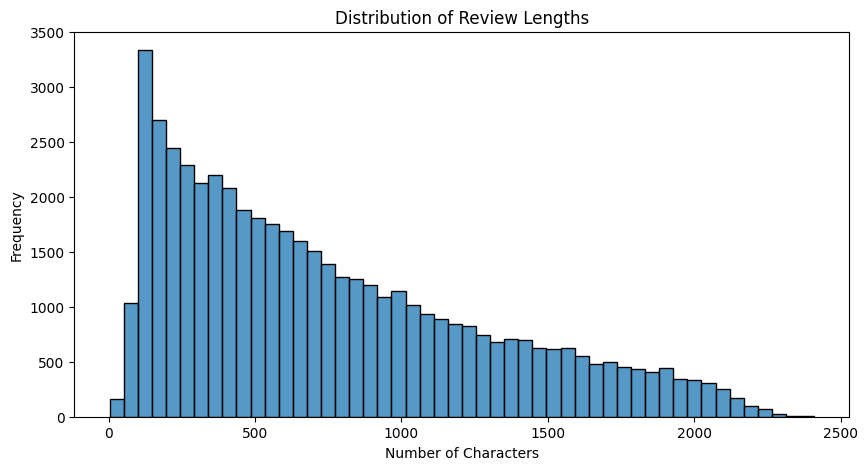

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['review_length'], bins=50)
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

Average Review Length by Rating

overall
0.0    659.038068
1.0    830.525103
2.0    827.207779
3.0    820.211986
4.0    699.910582
Name: review_length, dtype: float64


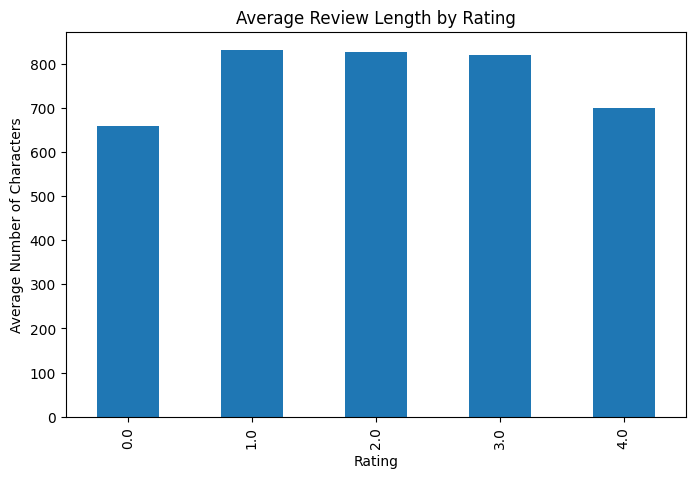

In [11]:
avg_length = df.groupby('overall')['review_length'].mean()

print(avg_length)

plt.figure(figsize=(8, 5))
avg_length.plot(kind='bar')
plt.title('Average Review Length by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Number of Characters')
plt.show()

Business Questions This Answers
Do dissatisfied customers write longer reviews?
Are negative reviews more detailed?
Which reviews are likely to contain the richest insights?

Common Industry Observation
Negatives reviews are often longer customers explain:
What went wrong
Why theya are frustrated
What should be improved


Create Sentiment Labels

In [12]:
def map_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

# Create sentiment column
df["sentiment"] = df["overall"].apply(map_sentiment)

# Check distribution
print(df["sentiment"].value_counts())

# Preview first rows
df[["overall", "sentiment"]].head()

sentiment
positive    26650
neutral     11897
negative    11453
Name: count, dtype: int64


,overall,sentiment
0,0.0,negative
1,3.0,neutral
2,0.0,negative
3,3.0,neutral
4,3.0,neutral


Save the processed dataset

In [13]:
processed_path = os.path.join(DATA_PATH, "amazon_reviews_processed.csv")
df.to_csv(processed_path, index=False)

print("Processed dataset saved successfully!")
print("Final shape:", df.shape)

Processed dataset saved successfully!
Final shape: (50000, 12)


Step 2.3: Extract Negative Reviews for Business Insight Mining


Companies care most about negative reviews because they reveal:

. Product defects
. Battery issues
. Delivery problems
. Packaging complaints
. Customer support failures

In [14]:
#Filter Negative Reviews
# Select only negative reviews
negative_df = df[df["sentiment"] == "negative"].copy()

print("Number of negative reviews:", negative_df.shape[0])

# Show sample negative reviews
negative_df[["overall", "summary", "reviewText"]].head(10)

Number of negative reviews: 11453


,overall,summary,reviewText
0,0.0,Pay to unlock content? I don't think so.,Installing the game was a struggle (because of...
2,0.0,Wrong key,1st shipment received a book instead of the ga...
6,0.0,Crash 3 is correct name AKA Microsoft,I can't tell you what a piece of dog**** this ...
8,1.0,Couldn't get this one to work,I still haven't figured this one out. Did ever...
12,0.0,"It might have been a good game, but I never fo...",I bought this and the key didn't work. It was...
13,0.0,Don't waste your money,Crashed in Vista. Codemasters told me they do...
14,0.0,Not as good as DiRT 2,"This game was a rip-off. It has less terrain,..."
15,2.0,"Better than Dirt 2, Except for....",This really is a step up from Dirt 2. Better g...
16,0.0,Colin McRae CRASH 3!,This game is bug landFirst had problems instal...
17,0.0,The first one was much better.,DiRT 2 was like this. I'm becoming more & mor...


Save Negative Reviws


In [15]:
negative_path = os.path.join(DATA_PATH, "negative_reviews.csv")

negative_df.to_csv(negative_path, index=False)

print(f"Negative reviews saved to: {negative_path}")

Negative reviews saved to: /content/drive/MyDrive/AI_Projects/Customer_Review_Insight_Engine/data/negative_reviews.csv


Inspect a few Complaints

In [16]:
for i, review in enumerate(negative_df["reviewText"].head(5), 1):
    print(f"\n--- Review {i} ---\n")
    print(review[:1000])  # Print first 1000 characters


--- Review 1 ---

Installing the game was a struggle (because of games for windows live bugs).Some championship races and cars can only be "unlocked" by buying them as an addon to the game. I paid nearly 30 dollars when the game was new. I don't like the idea that I have to keep paying to keep playing.I noticed no improvement in the physics or graphics compared to Dirt 2.I tossed it in the garbage and vowed never to buy another codemasters game. I'm really tired of arcade style rally/racing games anyway.I'll continue to get my fix from Richard Burns Rally, and you should to. :)http://www.amazon.com/Richard-Burns-Rally-PC/dp/B000C97156/ref=sr_1_1?ie=UTF8&qid;=1341886844&sr;=8-1&keywords;=richard+burns+rallyThank you for reading my review! If you enjoyed it, be sure to rate it as helpful.

--- Review 2 ---

1st shipment received a book instead of the game.2nd shipment got a FAKE one. Game arrived with a wrong key inside on sealed box. I got in contact with codemasters and send them pict

Step 2.4: Discover Top Complaint Themes Using TF-IDF

Now we will automatically identify the most important words appearing in negative reviews.

This is one of the simplest and most effective NLP techniques for extracting recurring issues.

🧠 What is TF-IDF?

TF-IDF (Term Frequency–Inverse Document Frequency) assigns higher importance to words that:

Appear frequently in your documents
Are not common across all documents

For example:

key
install
fake
work
disc
windows

These words help reveal major complaint categories.

Extract Top Keywords from Negative Reviews

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Use review text and remove missing values
texts = negative_df["reviewText"].dropna().astype(str)

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000,
    ngram_range=(1, 2),   # single words + two-word phrases
    min_df=5
)

# Fit and transform
X = vectorizer.fit_transform(texts)

# Compute average TF-IDF score for each term
scores = X.mean(axis=0).A1
terms = vectorizer.get_feature_names_out()

# Create DataFrame of terms and scores
keywords_df = pd.DataFrame({
    "term": terms,
    "score": scores
})

# Top 30 keywords
top_keywords = keywords_df.sort_values(
    by="score",
    ascending=False
).head(30)

top_keywords

,term,score
333,game,0.117466
509,like,0.042790
479,just,0.039723
365,games,0.038733
387,good,0.035963
652,play,0.033725
397,graphics,0.031313
328,fun,0.030963
715,really,0.029064
885,time,0.027950


Visualize Top Complaint Keywords


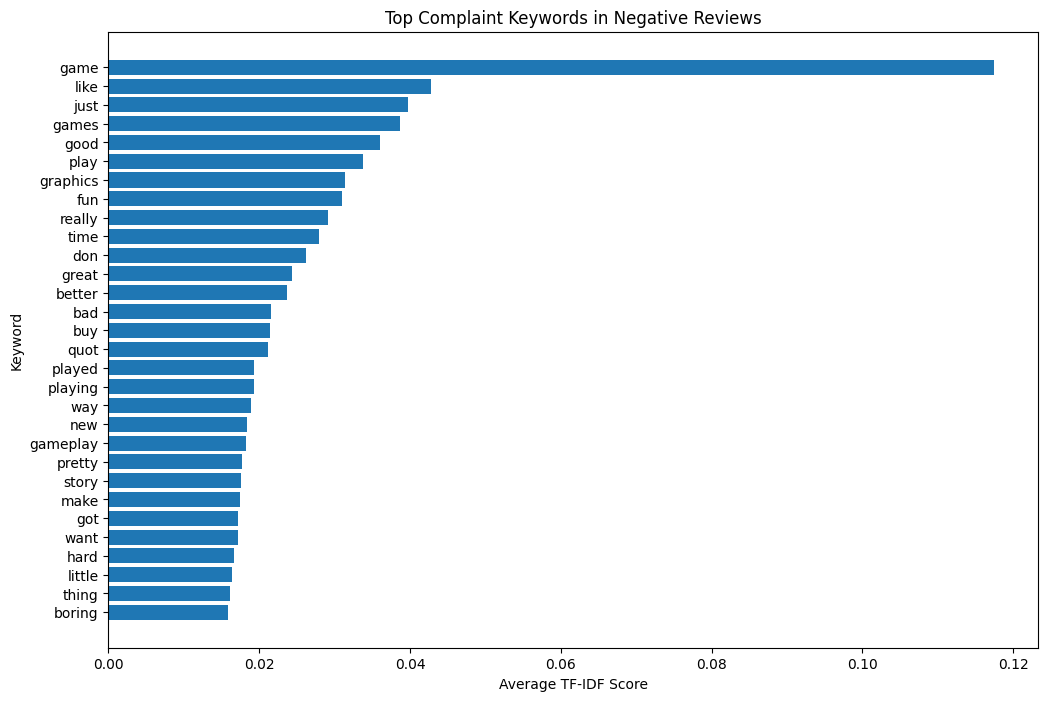

In [18]:
plt.figure(figsize=(12, 8))

# Reverse order for better horizontal bar chart display
plot_df = top_keywords.sort_values("score")

plt.barh(plot_df["term"], plot_df["score"])
plt.title("Top Complaint Keywords in Negative Reviews")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Keyword")
plt.show()

Save keywords to CSV

In [19]:
keywords_path = os.path.join(DATA_PATH, "top_complaint_keywords.csv")
top_keywords.to_csv(keywords_path, index=False)

print(f"Keywords saved to: {keywords_path}")

Keywords saved to: /content/drive/MyDrive/AI_Projects/Customer_Review_Insight_Engine/data/top_complaint_keywords.csv


🏢 Business Interpretation Example

If keywords like install, key, and fake dominate, it suggests:

Customers are experiencing software activation problems and counterfeit products.

A business could immediately:

Improve verification processes
Tighten seller controls
Reduce fraudulent listings

That is exactly the type of actionable insight your project is designed to uncover.

Step 2.5: Clustering Complaints Using Embeddings

In that step, we will use sentence-transformers to group similar complaints into meaningful themes such as:

Installation Issues
Fake Products
Product Defects
Compatibility Problems

Step 2.5: Cluster Similar Complaints Using Embeddings

We will use:

sentence-transformers/all-MiniLM-L6-v2
KMeans clustering
Real negative reviews

This will automatically group similar complaints into themes such as:

Installation Issues
Fake Products
Broken or Defective Items
Compatibility Problems
Poor Product Quality

🏢 Real-World Analogy

Imagine a company receives 10,000 complaints.

Instead of reading them one by one, AI groups them into categories automatically.

This allows product teams to immediately see the biggest customer pain points.

2.1 Prepare a sample of negative reviews


In [20]:
# Use a subset for faster experimentation
sample_size = 5000

negative_sample = (
    negative_df["reviewText"]
    .dropna()
    .astype(str)
    .head(sample_size)
    .tolist()
)

print("Number of reviews used:", len(negative_sample))
print("\nSample review:\n")
print(negative_sample[0][:500])

Number of reviews used: 5000

Sample review:

Installing the game was a struggle (because of games for windows live bugs).Some championship races and cars can only be "unlocked" by buying them as an addon to the game. I paid nearly 30 dollars when the game was new. I don't like the idea that I have to keep paying to keep playing.I noticed no improvement in the physics or graphics compared to Dirt 2.I tossed it in the garbage and vowed never to buy another codemasters game. I'm really tired of arcade style rally/racing games anyway.I'll cont


Generate Embeddings

In [21]:
from sentence_transformers import SentenceTransformer

# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings
embeddings = model.encode(
    negative_sample,
    show_progress_bar=True
)

print("Embeddings shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Embeddings shape: (5000, 384)


KMeans Clustering

In [22]:
from sklearn.cluster import KMeans

n_clusters = 8

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(embeddings)

print("Clustering completed!")

Clustering completed!


Create Cluster Dataframe


In [23]:
cluster_df = pd.DataFrame({
    "review": negative_sample,
    "cluster": cluster_labels
})

cluster_df.head()

,review,cluster
0,Installing the game was a struggle (because of...,1
1,1st shipment received a book instead of the ga...,2
2,I can't tell you what a piece of dog**** this ...,2
3,I still haven't figured this one out. Did ever...,5
4,I bought this and the key didn't work. It was...,2


Inpect Each Cluster

In [24]:
for cluster_id in range(n_clusters):
    print("\n" + "="*80)
    print(f"CLUSTER {cluster_id}")
    print("="*80)

    samples = cluster_df[cluster_df["cluster"] == cluster_id]["review"].head(3)

    for i, review in enumerate(samples, 1):
        print(f"\n--- Sample {i} ---\n")
        print(review[:600])


CLUSTER 0

--- Sample 1 ---

yeah the cpu is like  completley retarded gulie does not counter with his flip kicks ryu doesnt ever do his shukoken uppercuts to counter but  some of the characters can be pretty hard like T. Hawk but i just dont get the street fighter arcade - like feeling

--- Sample 2 ---

The sheer number of games bearing some form of the name &quot;Street Fighter II&quot; is staggering. So when Capcom announced that it was putting together a compilation of Street Fighter games, I was stoked. My excitement quickly cooled when I discovered the true nature of Capcom's package. Street Fighter Collection contains Super Street Fighter 2, Super Street Fighter 2 Turbo, and Street Fighter Alpha 2 Gold, a slightly updated version of Street Fighter Alpha 2. The original Street Fighter 2, Champion Edition, and Hyper Fighting are nowhere to be found. The result is a shallow package that sh

--- Sample 3 ---

To say that the PS1 version of Capcom's X-Men VS Street Fighter is butch

Save clustern Results


In [25]:
cluster_path = os.path.join(DATA_PATH, "negative_review_clusters.csv")
cluster_df.to_csv(cluster_path, index=False)

print(f"Cluster results saved to: {cluster_path}")

Cluster results saved to: /content/drive/MyDrive/AI_Projects/Customer_Review_Insight_Engine/data/negative_review_clusters.csv


Step 3: Build Semantic Search with ChromaDB
Now we will create a vector database so users can ask natural language questions such as:

“Show complaints about fake products.”
“Find installation issues.”
“What do customers say about broken items?”

What is ChromaDB?

ChromaDB is a vector database that stores:

Documents (reviews)
Embeddings (vectors)
Metadata

It allows semantic search based on meaning rather than exact keywords.

🏢 Real-Life Analogy

Think of ChromaDB as a super-intelligent library.

Instead of searching for exact words, it finds documents with similar meaning.

If you ask:

“fake product”

it may also retrieve reviews mentioning:

counterfeit item
invalid key
not genuine
bogus disc

In [27]:
import os
import json

# Base path
NOTEBOOKS_PATH = "/content/drive/MyDrive/AI_Projects/Customer_Review_Insight_Engine/notebooks"

# Notebook filename
notebook_name = "03_semantic_search_with_chromadb.ipynb"

# Full file path
notebook_path = os.path.join(NOTEBOOKS_PATH, notebook_name)

# Minimal valid Jupyter notebook structure
notebook_content = {
    "cells": [],
    "metadata": {
        "colab": {
            "name": notebook_name,
            "provenance": []
        },
        "kernelspec": {
            "display_name": "Python 3",
            "name": "python3"
        },
        "language_info": {
            "name": "python"
        }
    },
    "nbformat": 4,
    "nbformat_minor": 0
}

# Create notebook file
with open(notebook_path, "w") as f:
    json.dump(notebook_content, f, indent=2)

print(f"Notebook created successfully!")
print(f"Location: {notebook_path}")

Notebook created successfully!
Location: /content/drive/MyDrive/AI_Projects/Customer_Review_Insight_Engine/notebooks/03_semantic_search_with_chromadb.ipynb
